# Student Performance Prediction

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Generation (Dummy Data)

In [2]:
np.random.seed(42)

num_students = 100

study_hours = np.random.uniform(2, 15, num_students)
attendance = np.random.uniform(60, 100, num_students)
marks = 30 + (study_hours * 4) + (attendance * 0.5) + np.random.normal(0, 5, num_students)
marks = np.clip(marks, 0, 100)
data = pd.DataFrame({
    'Study Hours': study_hours,
    'Attendance': attendance,
    'Marks': marks
})

print("Generated dummy data for student performance:")
display(data.head())

Generated dummy data for student performance:


,Study Hours,Attendance,Marks
0,6.869022,61.257167,84.704546
1,14.359286,85.456416,100.000000
2,11.515921,72.574239,100.000000
3,9.782560,80.342828,100.000000
4,4.028242,96.302659,100.000000


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("Descriptive statistics for the dataset:")
display(data.describe())

Descriptive statistics for the dataset:


,Study Hours,Attendance,Marks
count,100.000000,100.000000,100.000000
mean,8.112350,79.913269,94.328379
std,3.867362,11.724450,8.456094
min,2.071788,60.278085,70.601393
25%,4.511610,69.680181,90.696724
50%,8.033852,80.224994,100.000000
75%,11.492641,90.647344,100.000000
max,14.829530,99.426018,100.000000


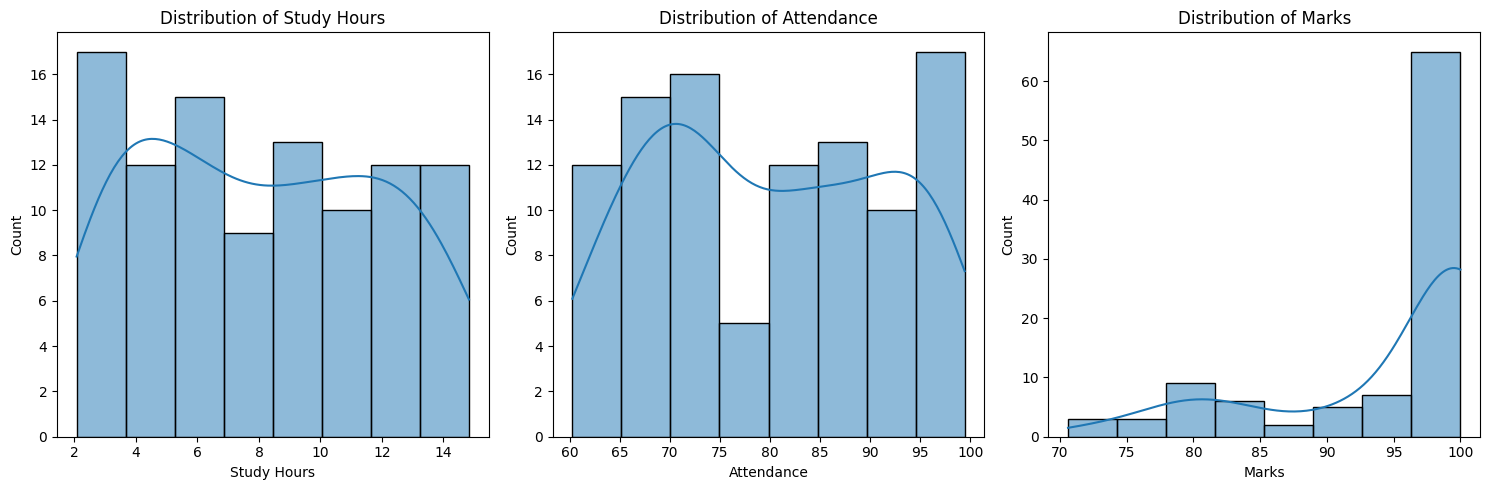

In [4]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data['Study Hours'], kde=True)
plt.title('Distribution of Study Hours')

plt.subplot(1, 3, 2)
sns.histplot(data['Attendance'], kde=True)
plt.title('Distribution of Attendance')

plt.subplot(1, 3, 3)
sns.histplot(data['Marks'], kde=True)
plt.title('Distribution of Marks')

plt.tight_layout()
plt.show()

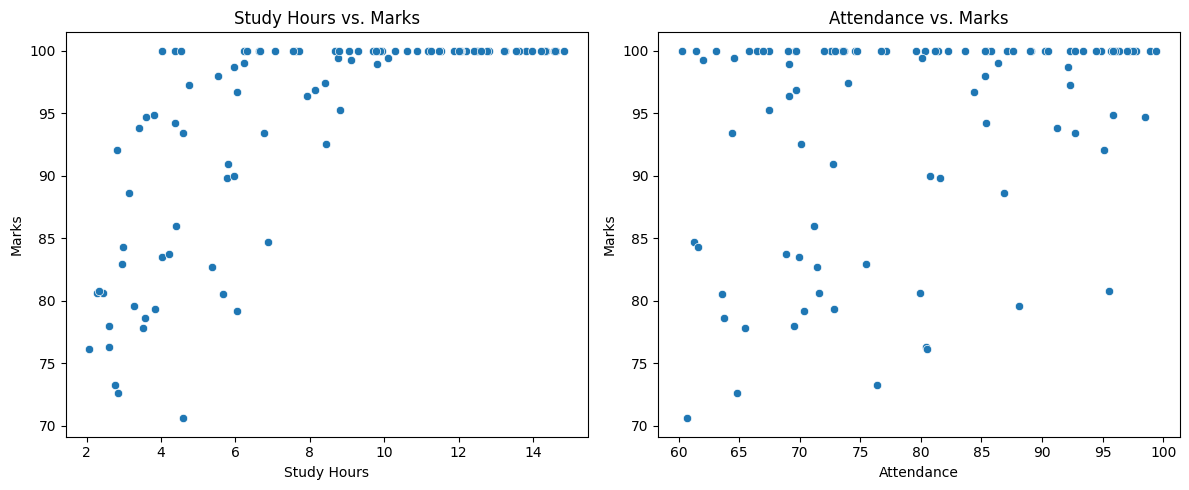

Pairplot of all variables:


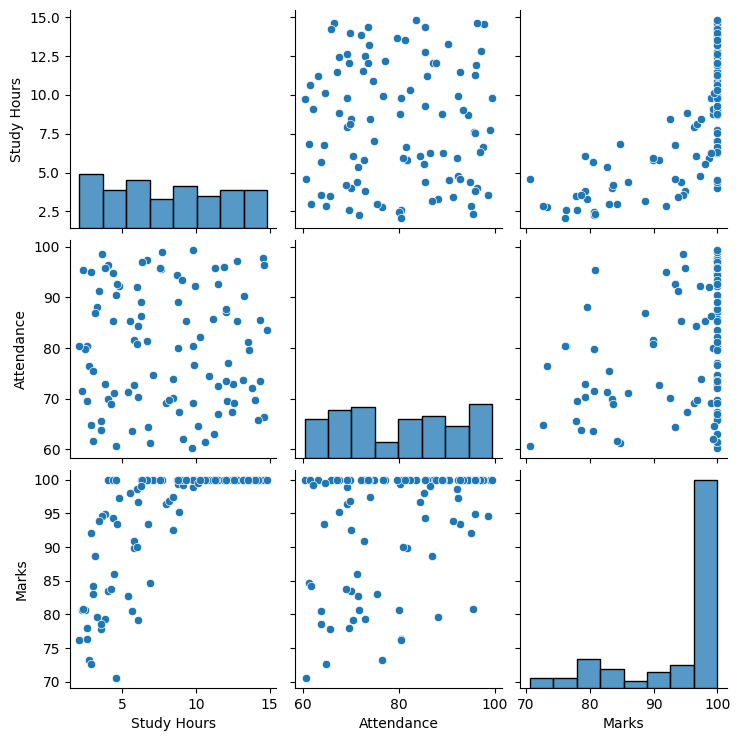

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Study Hours', y='Marks', data=data)
plt.title('Study Hours vs. Marks')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Attendance', y='Marks', data=data)
plt.title('Attendance vs. Marks')

plt.tight_layout()
plt.show()

print("Pairplot of all variables:")
sns.pairplot(data)
plt.show()

## 3. Data Preprocessing and Model Training

In [6]:
X = data[['Study Hours', 'Attendance']]
y = data['Marks']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {len(X_train)} samples")
print(f"Testing data size: {len(X_test)} samples")

Training data size: 80 samples
Testing data size: 20 samples


### 3.1. Linear Regression Model

In [7]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Coefficients: {linear_model.coef_}")
print(f"Intercept: {linear_model.intercept_}")

Linear Regression model trained successfully.
Coefficients: [1.63470878 0.24795145]
Intercept: 61.357990579977766


### 3.2. Random Forest Regressor Model

In [8]:
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


## 4. Model Evaluation

### 4.1. Evaluate Linear Regression Model

Linear Regression Model MAE: 3.24
Linear Regression Model R2 Score: 0.79


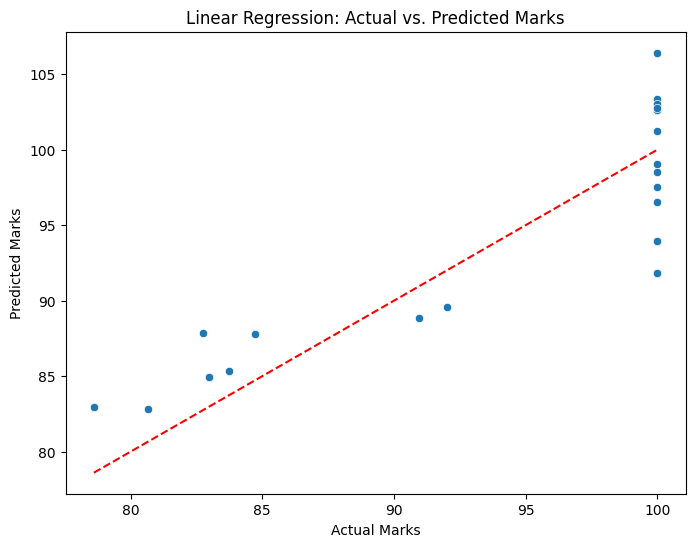

In [9]:
y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression Model MAE: {mae_linear:.2f}")
print(f"Linear Regression Model R2 Score: {r2_linear:.2f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_linear)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Linear Regression: Actual vs. Predicted Marks')
plt.show()

### 4.2. Evaluate Random Forest Regressor Model

Random Forest Regressor Model MAE: 1.92
Random Forest Regressor Model R2 Score: 0.80


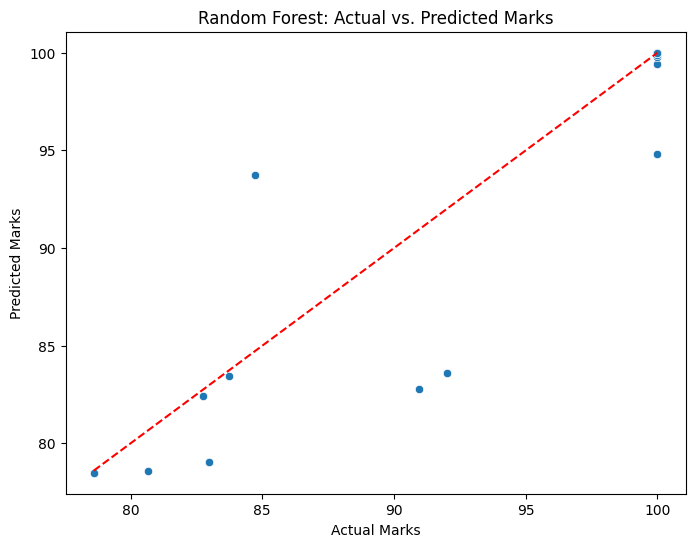

In [11]:
y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Model MAE: {mae_rf:.2f}")
print(f"Random Forest Regressor Model R2 Score: {r2_rf:.2f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Random Forest: Actual vs. Predicted Marks')
plt.show()

## 5. Conclusion and Comparison

In [12]:
print("\n--- Model Performance Comparison ---")
print(f"Linear Regression MAE: {mae_linear:.2f}, R2 Score: {r2_linear:.2f}")
print(f"Random Forest MAE: {mae_rf:.2f}, R2 Score: {r2_rf:.2f}")

print("\nBased on these metrics, we can compare the models and decide which performs better for this specific dataset and prediction task. Generally, a lower MAE and a higher R2 score indicate a better model.")



--- Model Performance Comparison ---
Linear Regression MAE: 3.24, R2 Score: 0.79
Random Forest MAE: 1.92, R2 Score: 0.80

Based on these metrics, we can compare the models and decide which performs better for this specific dataset and prediction task. Generally, a lower MAE and a higher R2 score indicate a better model.
